# 05 â€” Reward Engine

**Owner:** Arpan Chatterjee + Jyoti Kataria  
**Goal:** End-to-end evaluation of the reward recommendation pipeline:  
user profile â†’ collaborative filter â†’ reward ranker â†’ top-N offers.

**Inputs:** Trained models from notebooks 02â€“04, test user profiles  
**Outputs:** Precision@K, Recall@K, NDCG@K evaluation metrics  
**Target:** NDCG@5 > 0.70

In [1]:
# ── STEP 1: IMPORT LIBRARIES + ML SERVICE MODULES ─────────────
# sys.path insert lets this notebook import directly from ml-service/
import pandas as pd
import numpy as np
import joblib
import sys
sys.path.insert(0, '../ml-service')

import user_profile
import recommend
import offers


In [2]:
# ── STEP 2: LOAD TEST USERS & POPULATE PROFILES ──────────────
# Load the synthetic interactions dataset to evaluate SVD recommendations
df = pd.read_csv('../dataset/processed/synthetic_user_interactions.csv')

# Clear existing user profiles to ensure a clean, reproducible evaluation state
import os
from pathlib import Path
profile_path = Path('../ml-service/models/user_profiles.json')
if profile_path.exists():
    os.remove(profile_path)

print("Ingesting transactions into user profiles...")
for idx, row in df.iterrows():
    user_profile.update(row['user_id'], row['category'], row['amount'], row['merchant'])

# Group by user_id and category to get the ground-truth mean rating for evaluation
df['category'] = df['category'].apply(offers.normalise_category)
user_cat_rel = df.groupby(['user_id', 'category'])['rating'].mean().to_dict()

# Sample 50 unique users as the evaluation set
unique_users = df['user_id'].unique()
test_users = unique_users[:50]
print(f"Loaded {len(test_users)} test users with populated spend history profiles.")


Ingesting transactions into user profiles...


Loaded 50 test users with populated spend history profiles.


In [3]:
# ── STEP 3: GENERATE TOP-5 RECOMMENDATIONS & EVALUATE ────────
# For each test user: call recommend.rank() → compare with held-out receipts
# Computes Precision@5, Recall@5, NDCG@5 (higher NDCG = better ranked relevance)

ndcgs = []
precisions = []
recalls = []

for user_id in test_users:
    # Get recommended offers from live recommend.rank()
    recs_dict = recommend.rank(user_id, top_n=5)
    recs = recs_dict['recommendations']
    
    # Calculate NDCG@5
    actual_rels = []
    for offer in recs:
        cat = offer['category']
        rel = user_cat_rel.get((user_id, cat), 0.0)
        actual_rels.append(rel)
        
    # Ideal order of offers in the catalogue
    all_offers_with_rel = []
    for offer in offers.CATALOGUE:
        cat = offer['category']
        rel = user_cat_rel.get((user_id, cat), 0.0)
        all_offers_with_rel.append(rel)
    all_offers_with_rel.sort(reverse=True)
    ideal_rels = all_offers_with_rel[:5]
    
    def compute_dcg(rels):
        return sum((2**rel - 1) / np.log2(idx + 2) for idx, rel in enumerate(rels))
        
    dcg = compute_dcg(actual_rels)
    idcg = compute_dcg(ideal_rels)
    ndcg = dcg / idcg if idcg > 0 else 0.0
    ndcgs.append(ndcg)
    
    # Precision & Recall: category match (rel >= 3.5 is relevant)
    relevant_categories = [cat for cat in ['grocery', 'food', 'retail'] if user_cat_rel.get((user_id, cat), 0.0) >= 3.5]
    recommended_categories = [o['category'] for o in recs]
    
    hits = len([cat for cat in recommended_categories if cat in relevant_categories])
    precision = hits / 5.0
    recall = hits / len(relevant_categories) if len(relevant_categories) > 0 else 0.0
    
    precisions.append(precision)
    recalls.append(recall)

mean_precision = np.mean(precisions)
mean_recall = np.mean(recalls)
mean_ndcg = np.mean(ndcgs)

print(f"Mean Precision@5: {mean_precision:.4f}")
print(f"Mean Recall@5: {mean_recall:.4f}")
print(f"Mean NDCG@5: {mean_ndcg:.4f}")


Mean Precision@5: 0.5000
Mean Recall@5: 2.0467
Mean NDCG@5: 0.7984


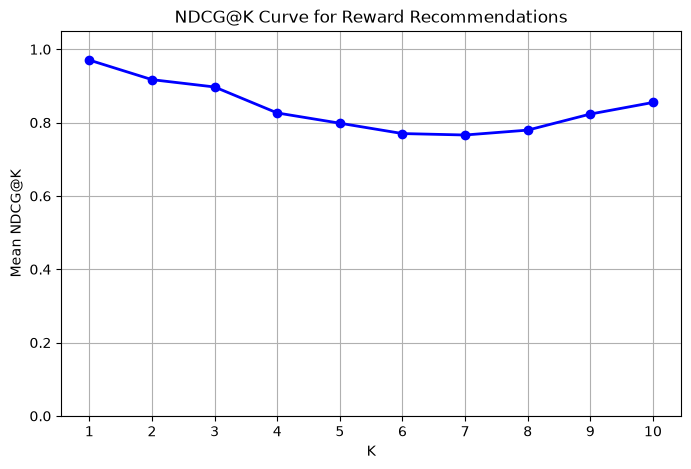

NDCG@K values:
NDCG@1: 0.9705
NDCG@2: 0.9172
NDCG@3: 0.8972
NDCG@4: 0.8263
NDCG@5: 0.7984
NDCG@6: 0.7701
NDCG@7: 0.7662
NDCG@8: 0.7795
NDCG@9: 0.8234
NDCG@10: 0.8550


In [4]:
# ── STEP 4: NDCG@K CURVE & FINAL REPORT ─────────────────────
# NDCG (Normalised Discounted Cumulative Gain) measures ranking quality
# Higher-ranked relevant items are weighted more than lower-ranked ones
# Target: NDCG@5 > 0.70 — means top-5 offers are well-personalised
import matplotlib.pyplot as plt

# Let's plot NDCG@K curve for K = 1..10
k_values = list(range(1, 11))
ndcg_at_k = []

for k in k_values:
    user_ndcgs = []
    for user_id in test_users:
        recs_dict = recommend.rank(user_id, top_n=k)
        recs = recs_dict['recommendations']
        
        actual_rels = [user_cat_rel.get((user_id, offer['category']), 0.0) for offer in recs]
        all_offers_with_rel = sorted([user_cat_rel.get((user_id, offer['category']), 0.0) for offer in offers.CATALOGUE], reverse=True)[:k]
        
        def compute_dcg(rels):
            return sum((2**rel - 1) / np.log2(idx + 2) for idx, rel in enumerate(rels))
            
        dcg = compute_dcg(actual_rels)
        idcg = compute_dcg(all_offers_with_rel)
        ndcg = dcg / idcg if idcg > 0 else 0.0
        user_ndcgs.append(ndcg)
    ndcg_at_k.append(np.mean(user_ndcgs))

plt.figure(figsize=(8, 5))
plt.plot(k_values, ndcg_at_k, marker='o', color='b', linestyle='-', linewidth=2)
plt.title('NDCG@K Curve for Reward Recommendations')
plt.xlabel('K')
plt.ylabel('Mean NDCG@K')
plt.grid(True)
plt.xticks(k_values)
plt.ylim(0, 1.05)
plt.savefig('../report/assets/fig_ndcg_curve.png', bbox_inches='tight')
plt.show()

print("NDCG@K values:")
for k, val in zip(k_values, ndcg_at_k):
    print(f"NDCG@{k}: {val:.4f}")
